### This notebook:

This notebook does the analysis part of the project. It creates the list of emotional, topical, israel and palestine words. Uses the last two to create the dimension in which to project to first two. Based on this results, shows descriptive statistics and runs t tests.

*Sources*:
- The helpers functions (apart from assign_score) come from the luccem_illud python package created for the computatinal content analysis (SOCI 40133) class.
- GPT - 4 was used in the debugging process to detect errors in the code.

In [1]:
from gensim.models import Word2Vec
import numpy as np
import sklearn.metrics
import pandas as pd
import random

### Helper functions and packages

In [2]:
def normalize(vector):
    """
    Normalize a vector for projection
    """
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def dimension(model, positives, negatives):
    """
    Creates a semantic dimension from two lists of words
    """
    diff = sum([normalize(model[x]) for x in positives]) - sum([normalize(model[y]) for y in negatives])
    return diff

def makeDF(model, word_list):
    """
    Projects a list of words onto a semantic dimension
    """
    isr_pal = []
    for word in word_list:
        isr_pal.append(sklearn.metrics.pairwise.cosine_similarity(model[word].reshape(1,-1), israel_palestine_dim.reshape(1,-1))[0][0])
    df = pd.DataFrame({'Dimension': isr_pal}, index = word_list)
    return df

def Coloring(Series):
    """
    Color for dimension graphs
    """
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    """
    Plots a semantic dimension
    """
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    ax.set_facecolor('none')
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 1, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

def assign_score (word, df, word_list):
    """
    Maps a word to a score on a semantic dimension
    """
    if word in word_list:
        return df.loc[word]['Dimension']

In [3]:
#load word2vec models
news_model = Word2Vec.load("news_word2vec.model")
social_media_model = Word2Vec.load("sm_word2vec.model")

## Emotional words

In [4]:
#Load emotion lexicon dictionary

dict_path = r"NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
nrc = pd.read_csv(dict_path, sep="\t", names=["word", "emotion", "association"], encoding = 'ISO-8859-1')
nrc = nrc[nrc.association == 1]

In [5]:
#create emotional word lists
emotional_words = nrc.word.unique().tolist()

emotional_words_in_news = [word for word in emotional_words if word in news_model.wv.key_to_index.keys()]
emotional_words_in_sm = [word for word in emotional_words if word in social_media_model.wv.key_to_index.keys()]


In [6]:
#create sample of word lists for visualization and testing

random.seed(123)
emotional_words_in_sm_sample = random.sample(emotional_words_in_sm, 15)
emotional_words_in_news_sample = random.sample(emotional_words_in_news, 15)

In [7]:
#most frequent emotional words in sm
word_freqs_em_sm = {}
for word in emotional_words_in_sm:
    word_freqs_em_sm[word] = social_media_model.wv.get_vecattr(word, "count")

#sort by keys
word_freqs_em_sm = dict(sorted(word_freqs_em_sm.items(), key=lambda item: item[1], reverse = True))
word_freqs_em_sm = {k: word_freqs_em_sm[k] for k in list(word_freqs_em_sm)[:5]}
word_freqs_em_sm

{'war': 26413, 'kill': 21075, 'land': 18359, 'time': 16221, 'attack': 14055}

In [8]:
#most frequent emotional words in news
word_freqs_em_news = {}
for word in emotional_words_in_news:
    word_freqs_em_news[word] = news_model.wv.get_vecattr(word, "count")

#sort by keys
word_freqs_em_news = dict(sorted(word_freqs_em_news.items(), key=lambda item: item[1], reverse = True))
word_freqs_em_news = {k: word_freqs_em_news[k] for k in list(word_freqs_em_news)[:5]}
word_freqs_em_news

{'attack': 5867, 'war': 5362, 'hostage': 4365, 'time': 3208, 'kill': 3090}

### Topical words

In [9]:
#Create list of topical words from the intercept article
# Not shown in code: started from a list of words from the article and selected similar using according to word2vec model
# (model.wv.most_similar('word', topn=10)

topical_words = ['journalist', 'children', 'boy', 'girl', 'hospital', 'kid', 'reporter', 'nurse', 'child', 'infant', 'disabled', 'elderly', 'orphan', 'mother']

topical_words_in_news = [word for word in topical_words if word in news_model.wv.key_to_index.keys()]
topical_words_in_sm = [word for word in topical_words if word in social_media_model.wv.key_to_index.keys()]


In [10]:
#frequency of topical words in sm
word_freqs_sm = {}
for word in topical_words_in_sm:
    word_freqs_sm[word] = social_media_model.wv.get_vecattr(word, "count")

#sort by keys
word_freqs_sm = dict(sorted(word_freqs_sm.items(), key=lambda item: item[1], reverse = True))
word_freqs_sm = {k: word_freqs_sm[k] for k in list(word_freqs_sm)[:5]}
word_freqs_sm

{'child': 12730,
 'hospital': 6821,
 'kid': 3885,
 'journalist': 1735,
 'reporter': 1123}

In [11]:
#frequency of topical words in news
word_freqs_news = {}
for word in topical_words_in_news:
    word_freqs_news[word] = news_model.wv.get_vecattr(word, "count")

#sort by keys
word_freqs_news = dict(sorted(word_freqs_news.items(), key=lambda item: item[1], reverse = True))
word_freqs_news = {k: word_freqs_news[k] for k in list(word_freqs_news)[:5]}
word_freqs_news

{'hospital': 2822,
 'child': 2129,
 'journalist': 503,
 'mother': 497,
 'reporter': 356}

### Dimension scores

In [12]:
#load models
from gensim.models import Word2Vec

#create list of words
pal_words = [w[0] for w in social_media_model.wv.most_similar('palestine', topn=30) if w[0].startswith('pal')]
pal_words_ham = [w[0] for w in social_media_model.wv.most_similar('hammas', topn=30) if w[0].startswith('ham')]
pal_words = pal_words + pal_words_ham

isr_words = [w[0] for w in social_media_model.wv.most_similar('israel', topn=30) if w[0].startswith('isr')]
isr_words = isr_words + ['idf', 'idfs', 'iof']

# create dimension
israel_palestine_dim = dimension(social_media_model.wv, isr_words, pal_words)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


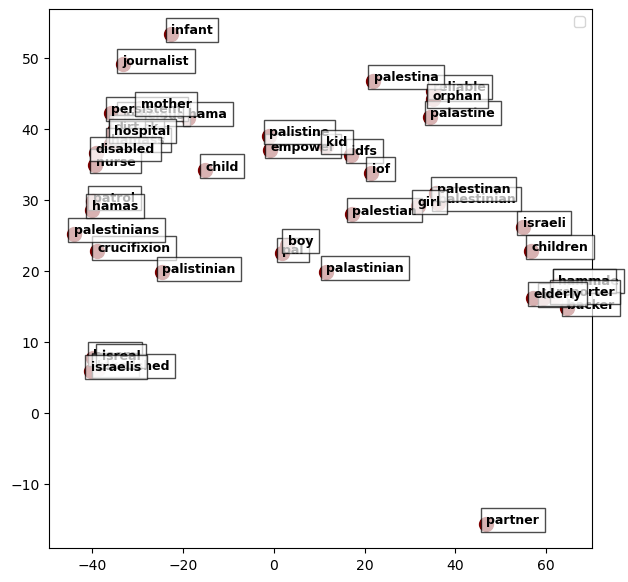

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Do tsne and graph reduced dimensionality embeddings space

tsne = TSNE(n_components=2, random_state=0)
embeddings_2d = tsne.fit_transform(social_media_model.wv.vectors)

word_for_graph = {}
for word in emotional_words_in_sm_sample:
    word_for_graph[word] = 'maroon'
for word in isr_words:
    word_for_graph[word] = 'maroon'
for word in pal_words:
    word_for_graph[word] = 'maroon'
for word in topical_words_in_sm:
    word_for_graph[word] = 'maroon'

plt.figure(figsize=(7, 7))
for i, word in enumerate(word_for_graph.keys()):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=word_for_graph[word], s=100)
    plt.text(embeddings_2d[i, 0]+0.05, embeddings_2d[i, 1]+0.05, word, fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

plt.legend()
plt.show()

In [14]:
#projections
projection_news_emotion = makeDF(news_model.wv, emotional_words_in_news)
projection_news_topical = makeDF(news_model.wv, topical_words_in_news)

projection_sm_emotion = makeDF(social_media_model.wv, emotional_words_in_sm)
projection_sm_topical = makeDF(social_media_model.wv, topical_words_in_sm)


In [15]:
#Assign scores to words
EmotionDF_sm = makeDF(social_media_model.wv, emotional_words_in_sm)
TopicalDF_sm = makeDF(social_media_model.wv, topical_words_in_sm)

EmotionDF_news = makeDF(news_model.wv, emotional_words_in_news)
TopicalDF_news = makeDF(news_model.wv, topical_words_in_news)


C:\Users\Ethan\AppData\Local\Temp\ipykernel_4044\276661666.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 1, fontsize = 12)


Text(0.5, 1.0, '')

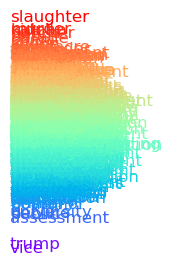

In [16]:
import matplotlib.pyplot as plt

#graph example of dimension
fig = plt.figure(figsize = (5,3))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, EmotionDF_news, 'Dimension')
ax1.set_title('')

In [17]:
#add emotional scores to nrc
nrc['score'] = nrc['word'].apply(lambda x: assign_score(x, EmotionDF_sm, emotional_words_in_sm))
nrc_sm = nrc.dropna()
nrc['score'] = nrc['word'].apply(lambda x: assign_score(x, EmotionDF_news, emotional_words_in_news))
nrc_news = nrc.dropna()

### Analysis

In [18]:
#Crating a dataframe with the scores of the words in the nrc lexicon
nrc_analysis = nrc.dropna()
nrc_analysis

,word,emotion,association,score
23,abandon,fear,1,0.029410
25,abandon,negative,1,0.029410
27,abandon,sadness,1,0.029410
76,abba,positive,1,-0.096583
133,abduction,fear,1,0.194160
...,...,...,...,...
141394,zeal,joy,1,0.078449
141396,zeal,positive,1,0.078449
141398,zeal,surprise,1,0.078449
141399,zeal,trust,1,0.078449


Descriptive stats

In [19]:
EmotionDF_sm.describe()

,Dimension
count,4133.000000
mean,-0.032271
std,0.113862
min,-0.443683
25%,-0.111813
50%,-0.036422
75%,0.042536
max,0.348459


In [20]:
EmotionDF_news.describe()

,Dimension
count,2599.000000
mean,0.031916
std,0.093143
min,-0.368856
25%,-0.029037
50%,0.030217
75%,0.091159
max,0.381332


In [21]:
TopicalDF_sm.describe()

,Dimension
count,14.000000
mean,0.022356
std,0.094083
min,-0.103974
25%,-0.043988
50%,-0.005954
75%,0.089747
max,0.202981


In [22]:
TopicalDF_news.describe()

,Dimension
count,14.000000
mean,0.088463
std,0.140331
min,-0.203074
25%,-0.005427
50%,0.123061
75%,0.166249
max,0.299881


T-tests

In [23]:
#run a t-test to see if the means are different
import scipy.stats as stats

In [24]:
stats.ttest_ind(EmotionDF_sm, EmotionDF_news)

TtestResult(statistic=array([-24.110037], dtype=float32), pvalue=array([0.], dtype=float32), df=array([6730.]))

In [25]:
stats.ttest_ind(TopicalDF_sm, TopicalDF_news)

TtestResult(statistic=array([-1.4640384], dtype=float32), pvalue=array([0.15517034], dtype=float32), df=array([26.]))